## 사용자 행동 인식 데이터셋
1. UCI 머신러닝 리포지토리(Machine Learning Repository)에서 제공
2. 사용자 행동 인식(Human Activity Recognition) 데이터셋
3. 30명에게 스마트폰 센서를 장착한 뒤 사람의 동작과 관련된 여러 피처를 수집한 데이터

In [1]:
### features의 명칭 확인
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#features.txt. 파일에는 피처 이름 인덱스와 피처명이 공백으로 분리되어 있음. Dataframe으로 로드
feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+', header=None, names=['column_index', 'column_name'])
#피처명 인덱스를 제거하고 피처명만 리스트 객체로 생성한 뒤, 샘플로 10개만 추출
feature_name = feature_name_df.iloc[:, 1].values.tolist()
print('전체 피처명에서 10개만 추출 : ', feature_name[:10])

전체 피처명에서 10개만 추출 :  ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


### feature
1. 인체의 움직임과 관련된 속성의 평균/표준편차가 X, Y, Z축 값으로 되어 있음
2. txt파일은 중복된 피처명을 가지고 있음 -> DataFrame으로 로딩하면 오류남 -> 중복 피처명에 _1, _2를 추가로 부여해 변경한 뒤에 DataFrame에 로드해야 함

In [2]:
### feature 중복 파악
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index']>1].count()) #42개가 중복되어 있음
feature_dup_df[feature_dup_df['column_index']>1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [3]:
### feature 중복 제거하는 함수
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x: str(x[0]) + '_' + str(x[1]) if x[1]>0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [4]:
### train 폴더의 학습용피처/레이블 데이터셋, test 폴더의 테스트피처 데이터/레이블 파일 각각 로드하는 함수
def get_human_dataset():
    # 각 데이터파일은 공백으로 분리됨 -> sep을 공백으로 할당
    feature_name_df = pd.read_csv(r'./human_activity/features.txt', sep='\+', header=None, names=['column_index', 'column_name'])
    # 중복된 피처명 수정하는 함수 이용
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    # DataFrame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    # 학습 피처 데이터셋과 테스트 피처 데이터셋을 dataFrame으로 로딩
    x_train = pd.read_csv(r'./human_activity/train/X_train.txt', sep='\s+', names=feature_name)
    x_test = pd.read_csv(r'./human_activity/test/X_test.txt', sep='\s+', names=feature_name)
    #학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩. 칼럼명은 action 으로 부여
    y_train = pd.read_csv(r'./human_activity/train/y_train.txt', sep='\s+', header=None, names=['action'])
    y_test = pd.read_csv(r'./human_activity/test/y_test.txt', sep='\s+', header=None, names=['action'])
    #로드된 학습/테스트용 DataFrame을 모두 반환
    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = get_human_dataset()

<ipython-input-4-021f58e97c53>:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  feature_name_df = pd.read_csv(r'./human_activity/features.txt', sep='\+', header=None, names=['column_index', 'column_name'])


In [5]:
print('** 학습 피처 데이터셋 info()')
print(x_train.info()) #피처가 전부 float 형 숫자이므로 별도의 카테코리 인코딩 필요 없음

** 학습 피처 데이터셋 info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, nan to nan_560.0
dtypes: float64(561)
memory usage: 31.5 MB
None


In [6]:
print(y_train['action'].value_counts())

6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: action, dtype: int64


### 사이킷런의 DecisionTreeClassifier을 이용해 동작 예측 분류 수행

In [7]:
### 하이퍼 파라미터 추출
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#예제 반복 시마다 동일한 에측 결과 도출 위해 random_state 설정
dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(x_train, y_train)
pred = dt_clf.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print('결정 트리 예측 정확도 : {0:.4f}'.format(accuracy))

# DecisionTreeClassifier의 하이퍼 파라미터 추출
print('DecisionTreeClassifier 기본 하이퍼 파라미터 : \n', dt_clf.get_params())

결정 트리 예측 정확도 : 0.8548
DecisionTreeClassifier 기본 하이퍼 파라미터 : 
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_impurity_split': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'presort': 'deprecated', 'random_state': 156, 'splitter': 'best'}


In [9]:
### tree depth가 예측 정확도에 주는 영향 - GridSearchCV 이용
from sklearn.model_selection import GridSearchCV

params = {'max_depth' : [6, 8, 10, 12, 16, 20, 24]}
grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(x_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치 : {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터 : ', grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  35 out of  35 | elapsed:  3.8min finished


GridSearchCV 최고 평균 정확도 수치 : 0.8513
GridSearchCV 최적 하이퍼 파라미터 :  {'max_depth': 16}


In [10]:
#GridSearchCV 객체의 cv_results_ 속성을 DataFrame으로 생성
cv_results_df = pd.DataFrame(grid_cv.cv_results_)
#max_depth 파라미터 값과 그때의 테스트 세트, 학습 데이터 세트의 정확도 수치 추출 - 5개 CV tpxmdptj 검증용 데이터세트 대상
cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.850791
1,8,0.851069
2,10,0.851209
3,12,0.844135
4,16,0.851344
5,20,0.850800
6,24,0.849440


In [11]:
### 별도의 테스트 데이터세트에서 max_depth 대한 결정 트리 정확도 측정 <- 위 계산 시 max_depth=8일때 가장 좋은 성능
max_depths = [6, 8, 10, 12, 16, 20, 24]
#파라미터를 변화시키면서 그때마다 학습과 테스트 세트에서 예측 성능 측정
for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth, random_state = 156)
    dt_clf.fit(x_train, y_train)
    pred = dt_clf.predict(x_test)
    accuracy = accuracy_score(y_test, pred)
    print('max depth = {0} , 정확도 : {1:.4f}'.format(depth, accuracy))

max depth = 6 , 정확도 : 0.8558
max depth = 8 , 정확도 : 0.8707
max depth = 10 , 정확도 : 0.8673
max depth = 12 , 정확도 : 0.8646
max depth = 16 , 정확도 : 0.8575
max depth = 20 , 정확도 : 0.8548
max depth = 24 , 정확도 : 0.8548


In [12]:
### max_depth와 min_samples_split을 같이 변경하면서 정확도 성능 튜닝
params = {'max_depth':[8, 12, 16, 20],
         'min_samples_split':[16, 24],}
grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(x_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치 : {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터 : ', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:  4.5min finished


GridSearchCV 최고 평균 정확도 수치 : 0.8549
GridSearchCV 최적 하이퍼 파라미터 :  {'max_depth': 8, 'min_samples_split': 16}


In [13]:
### max_depth=8, min_samples_split=16일때 최고 정확도임
best_dt_clf = grid_cv.best_estimator_
pred1 = best_dt_clf.predict(x_test)
accuracy = accuracy_score(y_test, pred1)
print('결정트리 예측 정확도 : {0:.4f}'.format(accuracy))

결정트리 예측 정확도 : 0.8717


### 각 피처의 중요도를 막대그래프로 표현

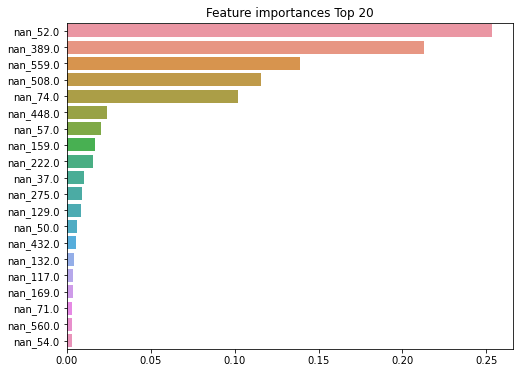

In [14]:
### feature_importances_ 속성 이용
import seaborn as sns

ftr_importances_values = best_dt_clf.feature_importances_
# top 중요로도 정렬을 쉽게&시본 막대 그래프로 쉽게 표현하기 위해 series 변환
ftr_importances = pd.Series(ftr_importances_values, index=x_train.columns)
#중요도값 순으로 series 정렬
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8, 6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()